In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/spaceship-titanic/sample_submission.csv
/kaggle/input/competitions/spaceship-titanic/train.csv
/kaggle/input/competitions/spaceship-titanic/test.csv


# **Step 1 — Load Dataset**

In [2]:
import pandas as pd
import numpy as np

train = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/test.csv')
sample_submission = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/sample_submission.csv')

In [3]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)
print("Sample Submission Shape:", sample_submission.shape)

Train Shape: (8693, 14)
Test Shape: (4277, 13)
Sample Submission Shape: (4277, 2)


# **Step 2 — Quick Dataset Preview**

In [4]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


# **Step 3 — Basic Dataset Information**

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


# **Step 4 — Statistical Summary**

In [7]:
train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


# **Step 5 — Target Distribution**

In [8]:
train['Transported'].value_counts()

Transported
True     4378
False    4315
Name: count, dtype: int64

In [9]:
train['Transported'].value_counts(normalize=True) * 100

Transported
True     50.362361
False    49.637639
Name: proportion, dtype: float64

<Axes: xlabel='Transported'>

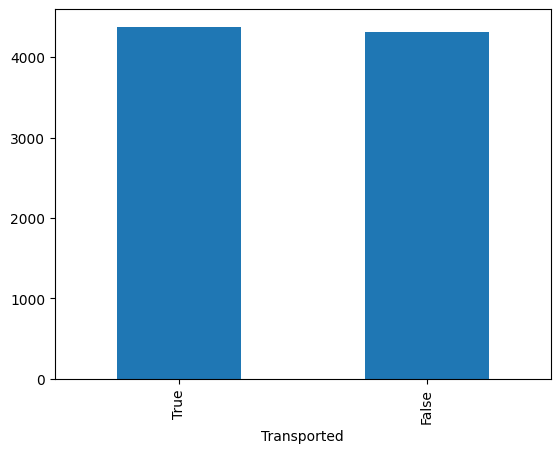

In [10]:
train['Transported'].value_counts().plot(kind='bar')

# **Step 6 — Data Types Count**

In [11]:
train.dtypes.value_counts()

object     7
float64    6
bool       1
Name: count, dtype: int64

# **Step 7 — Feature Understanding**

In [12]:
train.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')

# **Step 8 — Column Classification**

In [13]:
id_columns = ['PassengerId']

categorical_columns = [
    'HomePlanet',
    'CryoSleep',
    'Cabin',
    'Destination',
    'VIP',
    'Name'
]

numerical_columns = [
    'Age',
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck'
]

target_column = 'Transported'

print("ID Columns:", id_columns)
print("Categorical Columns:", categorical_columns)
print("Numerical Columns:", numerical_columns)
print("Target Column:", target_column)

ID Columns: ['PassengerId']
Categorical Columns: ['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']
Numerical Columns: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
Target Column: Transported


# **Step 9 — Check Unique Values**

In [14]:
train.nunique().sort_values()

CryoSleep          2
VIP                2
Transported        2
Destination        3
HomePlanet         3
Age               80
ShoppingMall    1115
RoomService     1273
VRDeck          1306
Spa             1327
FoodCourt       1507
Cabin           6560
Name            8473
PassengerId     8693
dtype: int64

# **Step 10 — Missing Values Percentage**

In [15]:
(train.isnull().sum() / len(train) * 100).sort_values(ascending=False)

CryoSleep       2.496261
ShoppingMall    2.392730
VIP             2.335212
HomePlanet      2.312205
Name            2.300702
Cabin           2.289198
VRDeck          2.162660
Spa             2.105142
FoodCourt       2.105142
Destination     2.093639
RoomService     2.082135
Age             2.059128
PassengerId     0.000000
Transported     0.000000
dtype: float64

# **Step 11 — Create Clean Copies**

In [16]:
train_clean = train.copy()
test_clean = test.copy()

print(train_clean.shape)
print(test_clean.shape)

(8693, 14)
(4277, 13)


# **Step 12 — Missing Values Handling (Numerical Columns)**

In [17]:
numerical_columns = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

for col in numerical_columns:
    median_value = train_clean[col].median()
    train_clean[col] = train_clean[col].fillna(median_value)
    test_clean[col] = test_clean[col].fillna(median_value)

print(train_clean[numerical_columns].isnull().sum())
print(test_clean[numerical_columns].isnull().sum())

Age             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
dtype: int64
Age             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
dtype: int64


# **Step 13 — Missing Values Handling (Categorical Columns)**

In [18]:
categorical_columns = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

for col in categorical_columns:
    mode_value = train_clean[col].mode()[0]
    train_clean[col] = train_clean[col].fillna(mode_value)
    test_clean[col] = test_clean[col].fillna(mode_value)

print(train_clean[categorical_columns].isnull().sum())
print(test_clean[categorical_columns].isnull().sum())

HomePlanet     0
CryoSleep      0
Destination    0
VIP            0
dtype: int64
HomePlanet     0
CryoSleep      0
Destination    0
VIP            0
dtype: int64


/tmp/ipykernel_16/242956776.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_clean[col] = train_clean[col].fillna(mode_value)
/tmp/ipykernel_16/242956776.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_clean[col] = test_clean[col].fillna(mode_value)


In [19]:
# fix the warning 
categorical_columns = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

for col in categorical_columns:
    mode_value = train_clean[col].mode()[0]
    train_clean[col] = train_clean[col].fillna(mode_value).infer_objects(copy=False)
    test_clean[col] = test_clean[col].fillna(mode_value).infer_objects(copy=False)

print(train_clean[categorical_columns].isnull().sum())
print(test_clean[categorical_columns].isnull().sum())

HomePlanet     0
CryoSleep      0
Destination    0
VIP            0
dtype: int64
HomePlanet     0
CryoSleep      0
Destination    0
VIP            0
dtype: int64


# **Step 14 — Cabin Missing Values Handle**

In [20]:
train_clean['Cabin'] = train_clean['Cabin'].fillna('Unknown/0/Unknown')
test_clean['Cabin'] = test_clean['Cabin'].fillna('Unknown/0/Unknown')

print(train_clean['Cabin'].isnull().sum())
print(test_clean['Cabin'].isnull().sum())

0
0


# **Step 15 — Cabin Split into 3 Features**

In [21]:
train_clean[['Deck', 'CabinNum', 'Side']] = train_clean['Cabin'].str.split('/', expand=True)
test_clean[['Deck', 'CabinNum', 'Side']] = test_clean['Cabin'].str.split('/', expand=True)

print(train_clean[['Cabin', 'Deck', 'CabinNum', 'Side']].head())

   Cabin Deck CabinNum Side
0  B/0/P    B        0    P
1  F/0/S    F        0    S
2  A/0/S    A        0    S
3  A/0/S    A        0    S
4  F/1/S    F        1    S


# **Step 16 — Convert CabinNum to Numeric**

In [22]:
train_clean['CabinNum'] = pd.to_numeric(train_clean['CabinNum'], errors='coerce')
test_clean['CabinNum'] = pd.to_numeric(test_clean['CabinNum'], errors='coerce')

print(train_clean['CabinNum'].dtype)
print(test_clean['CabinNum'].dtype)

int64
int64


# **Step 17 — Check All Missing Values (Final Verification)**

In [23]:
print(train_clean.isnull().sum().sort_values(ascending=False))
print("---")
print(test_clean.isnull().sum().sort_values(ascending=False))

Name            200
PassengerId       0
HomePlanet        0
Cabin             0
CryoSleep         0
Age               0
VIP               0
RoomService       0
Destination       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Transported       0
Deck              0
CabinNum          0
Side              0
dtype: int64
---
Name            94
PassengerId      0
CryoSleep        0
HomePlanet       0
Destination      0
Age              0
VIP              0
Cabin            0
RoomService      0
FoodCourt        0
Spa              0
ShoppingMall     0
VRDeck           0
Deck             0
CabinNum         0
Side             0
dtype: int64


# **Step 18 — Handle the Name Column**

In [24]:
train_clean = train_clean.drop('Name', axis=1)
test_clean = test_clean.drop('Name', axis=1)

In [25]:
print(train_clean.isnull().sum().sum())
print(test_clean.isnull().sum().sum())

0
0


In [26]:
print(train_clean.columns.tolist())

['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'Deck', 'CabinNum', 'Side']


# **Step 19 — Drop Original Cabin Column**

In [27]:
train_clean = train_clean.drop('Cabin', axis=1)
test_clean = test_clean.drop('Cabin', axis=1)

print(train_clean.columns.tolist())

['PassengerId', 'HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'Deck', 'CabinNum', 'Side']


# **Step 20 — Check Unique Values in Categorical Columns (Before Encoding)**

In [28]:
categorical_columns = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']

for col in categorical_columns:
    print(col, ":", train_clean[col].unique())

HomePlanet : ['Europa' 'Earth' 'Mars']
CryoSleep : [False  True]
Destination : ['TRAPPIST-1e' 'PSO J318.5-22' '55 Cancri e']
VIP : [False  True]
Deck : ['B' 'F' 'A' 'G' 'Unknown' 'E' 'D' 'C' 'T']
Side : ['P' 'S' 'Unknown']


# **Step 21 — Convert Boolean Columns to 0/1**

In [29]:
train_clean['CryoSleep'] = train_clean['CryoSleep'].astype(int)
test_clean['CryoSleep'] = test_clean['CryoSleep'].astype(int)

train_clean['VIP'] = train_clean['VIP'].astype(int)
test_clean['VIP'] = test_clean['VIP'].astype(int)

print(train_clean[['CryoSleep', 'VIP']].head())

   CryoSleep  VIP
0          0    0
1          0    0
2          0    1
3          0    0
4          0    0


# **Step 22 — One-Hot Encode Remaining Categorical Columns**


In [30]:
categorical_to_encode = ['HomePlanet', 'Destination', 'Deck', 'Side']

train_clean = pd.get_dummies(train_clean, columns=categorical_to_encode, drop_first=True)
test_clean = pd.get_dummies(test_clean, columns=categorical_to_encode, drop_first=True)

print(train_clean.shape)
print(test_clean.shape)
print(train_clean.columns.tolist())

(8693, 25)
(4277, 24)
['PassengerId', 'CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'CabinNum', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown', 'Side_S', 'Side_Unknown']


# **Step 23 — Verify Train/Test Columns Match (Excluding Target)**

In [31]:
train_features = set(train_clean.columns) - {'Transported'}
test_features = set(test_clean.columns)

print("In train but not test:", train_features - test_features)
print("In test but not train:", test_features - train_features)

In train but not test: set()
In test but not train: set()


# **Step 24 — Prepare Data for Modeling (Train/Validation Split)**

In [32]:
from sklearn.model_selection import train_test_split

X = train_clean.drop(['PassengerId', 'Transported'], axis=1)
y = train_clean['Transported']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

(6954, 23) (1739, 23)
(6954,) (1739,)


# **Step 25 — Train a Baseline Model (Random Forest)**

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

val_predictions = model.predict(X_val)
val_accuracy = accuracy_score(y_val, val_predictions)

print("Validation Accuracy:", val_accuracy)

Validation Accuracy: 0.7947096032202415


# **Step 26 — Generate Submission File**

In [34]:
# Retrain on full training data
final_model = RandomForestClassifier(n_estimators=200, random_state=42)
final_model.fit(X, y)

# Prepare test features (same columns as X, excluding PassengerId)
X_test = test_clean.drop(['PassengerId'], axis=1)

# Predict
test_predictions = final_model.predict(X_test)

# Build submission dataframe
submission = pd.DataFrame({
    'PassengerId': test_clean['PassengerId'],
    'Transported': test_predictions
})

submission.to_csv('submission.csv', index=False)
print(submission.head())
print(submission.shape)

  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
(4277, 2)


# **Step 27 — Verify Against Sample Submission Format**

In [35]:
print(sample_submission.head())
print(sample_submission.dtypes)
print("---")
print(submission.dtypes)

  PassengerId  Transported
0     0013_01        False
1     0018_01        False
2     0019_01        False
3     0021_01        False
4     0023_01        False
PassengerId    object
Transported      bool
dtype: object
---
PassengerId    object
Transported      bool
dtype: object


# **Step 28 — Feature Engineering: Group Size**

In [36]:
train_clean['Group'] = train_clean['PassengerId'].str.split('_').str[0]
test_clean['Group'] = test_clean['PassengerId'].str.split('_').str[0]

group_sizes = train_clean['Group'].value_counts()
train_clean['GroupSize'] = train_clean['Group'].map(group_sizes)

group_sizes_test = test_clean['Group'].value_counts()
test_clean['GroupSize'] = test_clean['Group'].map(group_sizes_test)

print(train_clean[['PassengerId', 'Group', 'GroupSize']].head())

  PassengerId Group  GroupSize
0     0001_01  0001          1
1     0002_01  0002          1
2     0003_01  0003          2
3     0003_02  0003          2
4     0004_01  0004          1


# **Step 29 — Feature Engineering: Total Spending**

In [37]:
spend_columns = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

train_clean['TotalSpend'] = train_clean[spend_columns].sum(axis=1)
test_clean['TotalSpend'] = test_clean[spend_columns].sum(axis=1)

print(train_clean[spend_columns + ['TotalSpend']].head())

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck  TotalSpend
0          0.0        0.0           0.0     0.0     0.0         0.0
1        109.0        9.0          25.0   549.0    44.0       736.0
2         43.0     3576.0           0.0  6715.0    49.0     10383.0
3          0.0     1283.0         371.0  3329.0   193.0      5176.0
4        303.0       70.0         151.0   565.0     2.0      1091.0


# **Step 30 — Clean Up and Retrain Model**

In [38]:
train_clean = train_clean.drop('Group', axis=1)
test_clean = test_clean.drop('Group', axis=1)

# Rebuild X and y with new features
X = train_clean.drop(['PassengerId', 'Transported'], axis=1)
y = train_clean['Transported']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

val_predictions = model.predict(X_val)
val_accuracy = accuracy_score(y_val, val_predictions)

print("New Validation Accuracy:", val_accuracy)

New Validation Accuracy: 0.78953421506613


# **Step 31 — Check Feature Importance**

In [39]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

                      Feature  Importance
8                    CabinNum    0.149010
24                 TotalSpend    0.136885
1                         Age    0.112961
6                         Spa    0.087770
4                   FoodCourt    0.075821
3                 RoomService    0.075320
7                      VRDeck    0.072289
5                ShoppingMall    0.062932
0                   CryoSleep    0.057777
23                  GroupSize    0.036895
21                     Side_S    0.021100
9           HomePlanet_Europa    0.017367
18                     Deck_G    0.017126
17                     Deck_F    0.013658
12    Destination_TRAPPIST-1e    0.013380
10            HomePlanet_Mars    0.011436
16                     Deck_E    0.011327
14                     Deck_C    0.007135
11  Destination_PSO J318.5-22    0.006865
13                     Deck_B    0.005082
15                     Deck_D    0.003247
2                         VIP    0.001961
20               Deck_Unknown    0

# **Step 32 — Test Removing Redundant Individual Spend Columns**

In [40]:
spend_columns = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

X_v2 = train_clean.drop(['PassengerId', 'Transported'] + spend_columns, axis=1)
y_v2 = train_clean['Transported']

X_train_v2, X_val_v2, y_train_v2, y_val_v2 = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42)

model_v2 = RandomForestClassifier(n_estimators=200, random_state=42)
model_v2.fit(X_train_v2, y_train_v2)

val_predictions_v2 = model_v2.predict(X_val_v2)
val_accuracy_v2 = accuracy_score(y_val_v2, val_predictions_v2)

print("Accuracy without individual spend columns:", val_accuracy_v2)

Accuracy without individual spend columns: 0.7331799884991375


# **Step 33 — Try a Different Model (XGBoost) with All Features**

In [41]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_val)
xgb_accuracy = accuracy_score(y_val, xgb_predictions)

print("XGBoost Validation Accuracy:", xgb_accuracy)

XGBoost Validation Accuracy: 0.7952846463484762


# **Step 34 — Tune XGBoost Hyperparameters**

In [42]:
xgb_model_tuned = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)
xgb_model_tuned.fit(X_train, y_train)

xgb_tuned_predictions = xgb_model_tuned.predict(X_val)
xgb_tuned_accuracy = accuracy_score(y_val, xgb_tuned_predictions)

print("Tuned XGBoost Validation Accuracy:", xgb_tuned_accuracy)

Tuned XGBoost Validation Accuracy: 0.8039102932719954


# **Step 35 — Cross-Validation (Reliability Check)**

In [43]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(xgb_model_tuned, X, y, cv=5, scoring='accuracy')

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

CV Scores: [0.75963197 0.76250719 0.79298447 0.83199079 0.78193326]
Mean CV Accuracy: 0.7858095369810962
Std Dev: 0.0261819713672678


# **Step 36 — Finalize the Model**

In [44]:
final_xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)
final_xgb_model.fit(X, y)

X_test_final = test_clean.drop(['PassengerId'], axis=1)
final_predictions = final_xgb_model.predict(X_test_final)

print(final_predictions[:10])
print(len(final_predictions))

[1 0 1 1 1 1 1 1 1 1]
4277


# **Step 37 — Build Final Submission File**

In [45]:
final_predictions_bool = final_predictions.astype(bool)

submission_final = pd.DataFrame({
    'PassengerId': test_clean['PassengerId'],
    'Transported': final_predictions_bool
})

submission_final.to_csv('submission_final.csv', index=False)

print(submission_final.head())
print(submission_final.dtypes)
print(submission_final.shape)

  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
PassengerId    object
Transported      bool
dtype: object
(4277, 2)


# **Step 38 — Final Check**

In [46]:
print(submission_final['Transported'].value_counts())
print(submission_final['Transported'].value_counts(normalize=True) * 100)

Transported
True     2174
False    2103
Name: count, dtype: int64
Transported
True     50.830021
False    49.169979
Name: proportion, dtype: float64
